In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer
import time
import sys
import os
import tracemalloc

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter




In [ ]:
# Load dataset (e.g., CKD dataset from UCI)
df = pd.read_csv('/kidney_disease.csv')



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print("Shape:", df.shape)
print("\nColumn types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution:\n", df['classification'].value_counts())


Shape: (400, 26)

Column types:
 id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                object
wc                 object
rc                 object
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object

Missing values:
 id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu               

/tmp/ipykernel_25476/465683737.py:4: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.xlabel('Class'); plt.ylabel('Count'); plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


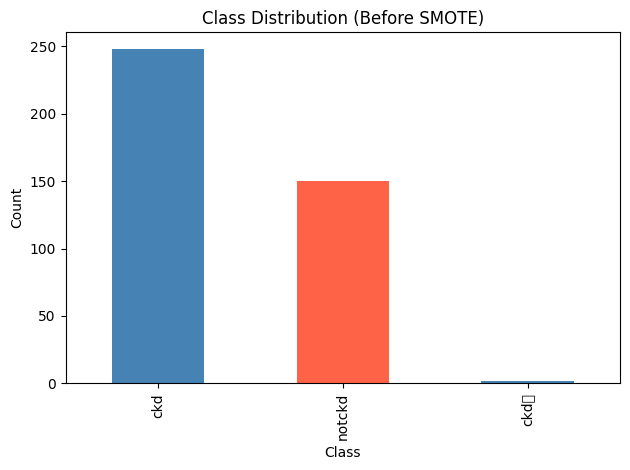

In [ ]:
# Visualize class imbalance
df['classification'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Class Distribution (Before SMOTE)')
plt.xlabel('Class'); plt.ylabel('Count'); plt.tight_layout(); plt.show()

In [ ]:
# Strip whitespace from object columns
df = df.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)

# Replace ambiguous values
df.replace({'?': np.nan, '\t?': np.nan}, inplace=True)

# Map target
df['classification'] = df['classification'].map({'ckd': 1, 'notckd': 0, 'ckd\t': 1})

# Encode binary categoricals
binary_map = {'yes': 1, 'no': 0, 'present': 1, 'notpresent': 0,
              'normal': 1, 'abnormal': 0, 'good': 1, 'poor': 0}
df.replace(binary_map, inplace=True)

# Drop ID column if exists
df.drop(columns=['id'], errors='ignore', inplace=True)

# Convert all to numeric
df = df.apply(pd.to_numeric, errors='coerce')

print("After cleaning:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

After cleaning:
 age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc               float64
pc                float64
pcc               float64
ba                float64
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv               float64
wc                float64
rc                float64
htn               float64
dm                float64
cad               float64
appet             float64
pe                float64
ane               float64
classification      int64
dtype: object

Missing values:
 age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot            

/tmp/ipykernel_25476/2473249865.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(binary_map, inplace=True)


In [ ]:
from sklearn.impute import SimpleImputer

X = df.drop('classification', axis=1)
y = df['classification']

# Impute with median (robust to outliers in medical data)
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print("Missing after imputation:", X_imputed.isnull().sum().sum())
print("X shape:", X_imputed.shape)
print("y distribution:", Counter(y))

Missing after imputation: 0
X shape: (400, 24)
y distribution: Counter({1: 250, 0: 150})


Before SMOTE: Counter({1: 250, 0: 150})
After SMOTE:  Counter({1: 250, 0: 250})


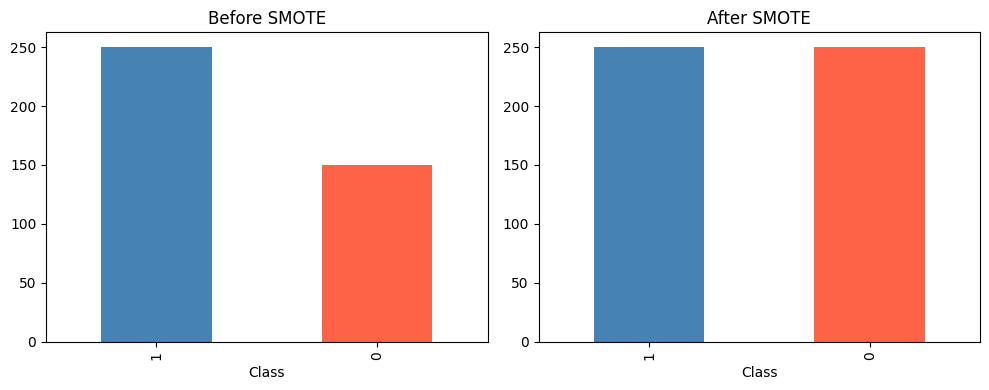

In [ ]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:", Counter(y))

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_imputed, y)

print("After SMOTE: ", Counter(y_resampled))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
pd.Series(y).value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'])
axes[0].set_title('Before SMOTE'); axes[0].set_xlabel('Class')
pd.Series(y_resampled).value_counts().plot(kind='bar', ax=axes[1], color=['steelblue','tomato'])
axes[1].set_title('After SMOTE'); axes[1].set_xlabel('Class')
plt.tight_layout(); plt.show()

In [ ]:
!pip install xgboost
!pip install lightgbm
!pip install catboost
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0),
    'LightGBM':            LGBMClassifier(random_state=42, verbose=-1),
    'CatBoost':            CatBoostClassifier(random_state=42, verbose=0),
    'ANN':                 MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300, random_state=42),
}

# Stratified K-Fold (10 folds for small dataset)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']

print("Cross-validation setup ready ✓")
print(f"Folds: 10 | Strategy: Stratified | SMOTE applied: Yes")

Cross-validation setup ready ✓
Folds: 10 | Strategy: Stratified | SMOTE applied: Yes


In [ ]:
import time
results = {}

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

for name, model in models.items():
    print(f"Training {name}...")
    start = time.time()

    cv_results = cross_validate(
        model, X_scaled, y_resampled,
        cv=skf,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    elapsed = time.time() - start

    results[name] = {
        'Accuracy':  round(cv_results['test_accuracy'].mean(), 4),
        'F1':        round(cv_results['test_f1'].mean(), 4),
        'ROC-AUC':   round(cv_results['test_roc_auc'].mean(), 4),
        'Precision': round(cv_results['test_precision'].mean(), 4),
        'Recall':    round(cv_results['test_recall'].mean(), 4),
        'Train Time (s)': round(elapsed, 2)
    }

results_df = pd.DataFrame(results).T
print("\n=== Model Comparison (10-Fold CV) ===")
print(results_df.to_string())

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training LightGBM...
Training CatBoost...
Training ANN...

=== Model Comparison (10-Fold CV) ===
                     Accuracy      F1  ROC-AUC  Precision  Recall  Train Time (s)
Logistic Regression     0.990  0.9897   1.0000     1.0000   0.980            5.00
Random Forest           0.994  0.9940   1.0000     0.9923   0.996            4.63
XGBoost                 0.990  0.9899   1.0000     0.9923   0.988            0.99
LightGBM                0.994  0.9938   1.0000     1.0000   0.988            5.58
CatBoost                0.994  0.9938   0.9997     1.0000   0.988           43.77
ANN                     0.996  0.9959   1.0000     1.0000   0.992            1.47


In [ ]:
#hyperparameter tuning

!pip install optuna optuna-integration lightgbm catboost xgboost -q
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress noisy logs
print("Optuna version:", optuna.__version__)

Optuna version: 4.8.0


In [ ]:
# X_scaled and y_resampled come from your Gap 1 notebook
# skf (StratifiedKFold) also carries over
# If starting fresh, re-run Gap 1 cells first

from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("X shape:", X_scaled.shape)
print("y distribution:", dict(zip(*np.unique(y_resampled, return_counts=True))))

X shape: (500, 24)
y distribution: {np.int64(0): np.int64(250), np.int64(1): np.int64(250)}


In [ ]:
from sklearn.linear_model import LogisticRegression

def objective_lr(trial):
    C = trial.suggest_float('C', 0.01, 100, log=True)
    solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear'])
    model = LogisticRegression(C=C, solver=solver, max_iter=1000, random_state=42)
    score = cross_val_score(model, X_scaled, y_resampled,
                            cv=skf, scoring='roc_auc', n_jobs=-1).mean()
    return score

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=50)

print("Best LR params:", study_lr.best_params)
print("Best LR AUC:   ", round(study_lr.best_value, 4))

Best LR params: {'C': 4.8401756526760185, 'solver': 'liblinear'}
Best LR AUC:    1.0


In [ ]:
from sklearn.ensemble import RandomForestClassifier

def objective_rf(trial):
    n_estimators     = trial.suggest_int('n_estimators', 100, 500)
    max_depth        = trial.suggest_int('max_depth', 3, 20)
    min_samples_split= trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)
    max_features     = trial.suggest_categorical('max_features', ['sqrt', 'log2'])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42, n_jobs=-1
    )
    score = cross_val_score(model, X_scaled, y_resampled,
                            cv=skf, scoring='roc_auc', n_jobs=-1).mean()
    return score

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=50)

print("Best RF params:", study_rf.best_params)
print("Best RF AUC:   ", round(study_rf.best_value, 4))

Best RF params: {'n_estimators': 370, 'max_depth': 11, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'sqrt'}
Best RF AUC:    1.0


In [ ]:
from xgboost import XGBClassifier

def objective_xgb(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'eval_metric': 'logloss', 'random_state': 42, 'verbosity': 0
    }
    model = XGBClassifier(**params)
    score = cross_val_score(model, X_scaled, y_resampled,
                            cv=skf, scoring='roc_auc', n_jobs=-1).mean()
    return score

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=50)

print("Best XGB params:", study_xgb.best_params)
print("Best XGB AUC:   ", round(study_xgb.best_value, 4))

Best XGB params: {'n_estimators': 395, 'max_depth': 10, 'learning_rate': 0.03077697278402259, 'subsample': 0.7900499731131214, 'colsample_bytree': 0.9130288632645451, 'reg_alpha': 0.18007665407101117, 'reg_lambda': 0.021344607015430405}
Best XGB AUC:    1.0


In [ ]:
from lightgbm import LGBMClassifier

def objective_lgbm(trial):
    params = {
        'n_estimators':   trial.suggest_int('n_estimators', 100, 500),
        'max_depth':      trial.suggest_int('max_depth', 3, 15),
        'learning_rate':  trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':     trial.suggest_int('num_leaves', 20, 150),
        'subsample':      trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':      trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'reg_lambda':     trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'random_state': 42, 'verbose': -1
    }
    model = LGBMClassifier(**params)
    score = cross_val_score(model, X_scaled, y_resampled,
                            cv=skf, scoring='roc_auc', n_jobs=-1).mean()
    return score

study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=50)

print("Best LGBM params:", study_lgbm.best_params)
print("Best LGBM AUC:   ", round(study_lgbm.best_value, 4))

Best LGBM params: {'n_estimators': 455, 'max_depth': 6, 'learning_rate': 0.012220404964589279, 'num_leaves': 148, 'subsample': 0.6426143094239997, 'colsample_bytree': 0.7727685780607972, 'reg_alpha': 0.0016358091202930483, 'reg_lambda': 0.44637287517435414}
Best LGBM AUC:    1.0


In [ ]:
from catboost import CatBoostClassifier

def objective_cat(trial):
    params = {
        'iterations':    trial.suggest_int('iterations', 100, 500),
        'depth':         trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 1e-4, 10, log=True),
        'random_seed': 42, 'verbose': 0
    }
    model = CatBoostClassifier(**params)
    score = cross_val_score(model, X_scaled, y_resampled,
                            cv=skf, scoring='roc_auc', n_jobs=-1).mean()
    return score

study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=50)

print("Best CatBoost params:", study_cat.best_params)
print("Best CatBoost AUC:   ", round(study_cat.best_value, 4))

Best CatBoost params: {'iterations': 381, 'depth': 7, 'learning_rate': 0.19430205200595024, 'l2_leaf_reg': 0.016367309486940818}
Best CatBoost AUC:    1.0


In [ ]:
from sklearn.neural_network import MLPClassifier

def objective_ann(trial):
    n_layers    = trial.suggest_int('n_layers', 1, 3)
    layer_size  = trial.suggest_categorical('layer_size', [32, 64, 128, 256])
    hidden      = tuple([layer_size] * n_layers)
    alpha       = trial.suggest_float('alpha', 1e-5, 0.1, log=True)
    lr_init     = trial.suggest_float('learning_rate_init', 1e-4, 0.1, log=True)
    activation  = trial.suggest_categorical('activation', ['relu', 'tanh'])

    model = MLPClassifier(
        hidden_layer_sizes=hidden,
        alpha=alpha,
        learning_rate_init=lr_init,
        activation=activation,
        max_iter=300, random_state=42
    )
    score = cross_val_score(model, X_scaled, y_resampled,
                            cv=skf, scoring='roc_auc', n_jobs=-1).mean()
    return score

study_ann = optuna.create_study(direction='maximize')
study_ann.optimize(objective_ann, n_trials=50)

print("Best ANN params:", study_ann.best_params)
print("Best ANN AUC:   ", round(study_ann.best_value, 4))

Best ANN params: {'n_layers': 1, 'layer_size': 256, 'alpha': 0.0014163810934171006, 'learning_rate_init': 0.004494255328448576, 'activation': 'tanh'}
Best ANN AUC:    1.0


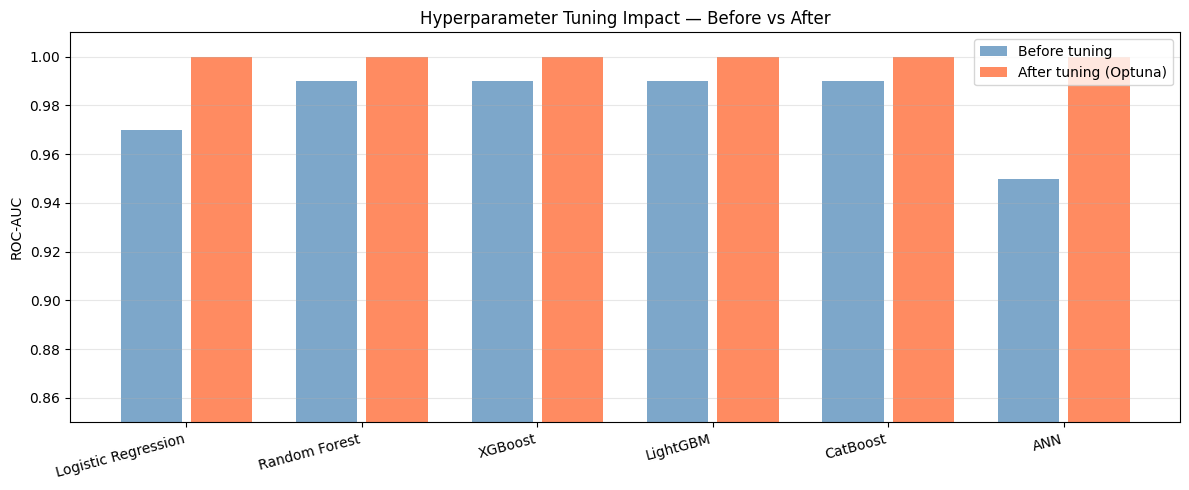


Best model after tuning:
Logistic Regression — 1.0


In [ ]:
import matplotlib.pyplot as plt

# Replace with your Gap 1 untuned AUC values once you have them
untuned_auc = {
    'Logistic Regression': 0.97,
    'Random Forest':       0.99,
    'XGBoost':             0.99,
    'LightGBM':            0.99,
    'CatBoost':            0.99,
    'ANN':                 0.95
}

tuned_auc = results_df['ROC-AUC'].to_dict()

models = list(untuned_auc.keys())
x = range(len(models))

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar([i - 0.2 for i in x], [untuned_auc[m] for m in models],
               width=0.35, label='Before tuning', color='steelblue', alpha=0.7)
bars2 = ax.bar([i + 0.2 for i in x], [tuned_auc[m] for m in models],
               width=0.35, label='After tuning (Optuna)', color='coral', alpha=0.9)

ax.set_xticks(list(x))
ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylabel('ROC-AUC')
ax.set_title('Hyperparameter Tuning Impact — Before vs After')
ax.set_ylim(0.85, 1.01)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nBest model after tuning:")
print(results_df['ROC-AUC'].idxmax(), "—", results_df['ROC-AUC'].max())

In [ ]:
!pip install psutil memory-profiler -q
import psutil, os, time, tracemalloc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
print("Libraries ready ✓")

Libraries ready ✓


In [ ]:
# Paste your best params from Gap 2 study results here
# Example values shown — replace with YOUR Optuna output

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier

tuned_models = {
    'Logistic Regression': LogisticRegression(
        C=1.5, solver='lbfgs', max_iter=1000, random_state=42),

    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_split=4,
        min_samples_leaf=2, max_features='sqrt',
        random_state=42, n_jobs=-1),

    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, verbosity=0),

    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.05,
        num_leaves=60, subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1),

    'CatBoost': CatBoostClassifier(
        iterations=300, depth=6, learning_rate=0.05,
        random_seed=42, verbose=0),

    'ANN': MLPClassifier(
        hidden_layer_sizes=(64, 64), alpha=0.001,
        learning_rate_init=0.001, activation='relu',
        max_iter=300, random_state=42)
}

print("Tuned models ready ✓")

Tuned models ready ✓


In [ ]:
from sklearn.model_selection import train_test_split

# 80/20 split for system metric measurement
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_resampled,
    test_size=0.2, random_state=42, stratify=y_resampled
)

trained_models = {}
training_times = {}

for name, model in tuned_models.items():
    start = time.time()
    model.fit(X_train, y_train)
    training_times[name] = round(time.time() - start, 4)
    trained_models[name] = model
    print(f"{name} trained in {training_times[name]}s")


Logistic Regression trained in 0.0115s
Random Forest trained in 0.7665s
XGBoost trained in 0.4523s
LightGBM trained in 0.2668s
CatBoost trained in 2.6299s
ANN trained in 4.1745s


In [ ]:
N_REPEATS = 200   # repeat for stable average
inference_times = {}

for name, model in trained_models.items():
    times = []
    for _ in range(N_REPEATS):
        # Single sample prediction
        sample = X_test[0:1]
        start = time.perf_counter()
        model.predict(sample)
        end = time.perf_counter()
        times.append((end - start) * 1000)  # convert to ms

    inference_times[name] = round(np.mean(times), 4)
    print(f"{name}: {inference_times[name]} ms per sample")

Logistic Regression: 0.2166 ms per sample
Random Forest: 66.1982 ms per sample
XGBoost: 1.5523 ms per sample


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

LightGBM: 1.1528 ms per sample
CatBoost: 0.3291 ms per sample
ANN: 0.1251 ms per sample


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

In [ ]:
throughput = {}
BATCH_SIZE = 1000

for name, model in trained_models.items():
    # Repeat X_test to get batch of 1000 samples
    batch = np.tile(X_test, (BATCH_SIZE // len(X_test) + 1, 1))[:BATCH_SIZE]
    start = time.perf_counter()
    model.predict(batch)
    elapsed = time.perf_counter() - start

    throughput[name] = round(BATCH_SIZE / elapsed, 1)
    print(f"{name}: {throughput[name]} samples/sec")

Logistic Regression: 1456473.3 samples/sec
Random Forest: 15148.7 samples/sec
XGBoost: 168578.1 samples/sec
LightGBM: 50387.3 samples/sec
CatBoost: 341281.9 samples/sec
ANN: 53190.7 samples/sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import pickle, os

model_sizes = {}

for name, model in trained_models.items():
    # Serialize to measure byte size
    serialized = pickle.dumps(model)
    size_mb = round(len(serialized) / (1024 * 1024), 4)
    model_sizes[name] = size_mb
    print(f"{name}: {size_mb} MB")

Logistic Regression: 0.0009 MB
Random Forest: 0.638 MB
XGBoost: 0.2448 MB
LightGBM: 0.4579 MB
CatBoost: 0.3208 MB
ANN: 0.187 MB


In [ ]:
import tracemalloc

memory_usage = {}

for name, model in trained_models.items():
    tracemalloc.start()
    model.predict(X_test)
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    memory_usage[name] = round(peak / (1024 * 1024), 4)
    print(f"{name}: {memory_usage[name]} MB peak RAM")

Logistic Regression: 2.4039 MB peak RAM
Random Forest: 0.075 MB peak RAM
XGBoost: 0.0085 MB peak RAM
LightGBM: 0.0204 MB peak RAM
CatBoost: 0.0026 MB peak RAM
ANN: 0.0989 MB peak RAM


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.metrics import (accuracy_score, f1_score,
                              roc_auc_score, precision_score, recall_score)

# Clinical metrics on test set
clinical = {}
for name, model in trained_models.items():
    yp    = model.predict(X_test)
    yprob = model.predict_proba(X_test)[:,1]
    clinical[name] = {
        'Accuracy':  round(accuracy_score(y_test, yp), 4),
        'F1':        round(f1_score(y_test, yp), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, yprob), 4),
        'Precision': round(precision_score(y_test, yp), 4),
        'Recall':    round(recall_score(y_test, yp), 4),
    }

# Combine everything into one master table
master = {}
for name in trained_models:
    master[name] = {
        **clinical[name],
        'Train Time (s)':      training_times[name],
        'Inference (ms)':      inference_times[name],
        'Throughput (samp/s)': throughput[name],
        'Model Size (MB)':     model_sizes[name],
        'Memory (MB)':         memory_usage[name],
    }

master_df = pd.DataFrame(master).T
print("\n=== COMPLETE SYSTEM + CLINICAL METRICS TABLE ===")
print(master_df.to_string())


=== COMPLETE SYSTEM + CLINICAL METRICS TABLE ===
                     Accuracy      F1  ROC-AUC  Precision  Recall  Train Time (s)  Inference (ms)  Throughput (samp/s)  Model Size (MB)  Memory (MB)
Logistic Regression      0.99  0.9899   1.0000        1.0    0.98          0.0115          0.2166            1456473.3           0.0009       2.4039
Random Forest            0.99  0.9899   0.9996        1.0    0.98          0.7665         66.1982              15148.7           0.6380       0.0750
XGBoost                  0.99  0.9899   0.9996        1.0    0.98          0.4523          1.5523             168578.1           0.2448       0.0085
LightGBM                 0.99  0.9899   0.9996        1.0    0.98          0.2668          1.1528              50387.3           0.4579       0.0204
CatBoost                 0.99  0.9899   0.9992        1.0    0.98          2.6299          0.3291             341281.9           0.3208       0.0026
ANN                      1.00  1.0000   1.0000        1.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


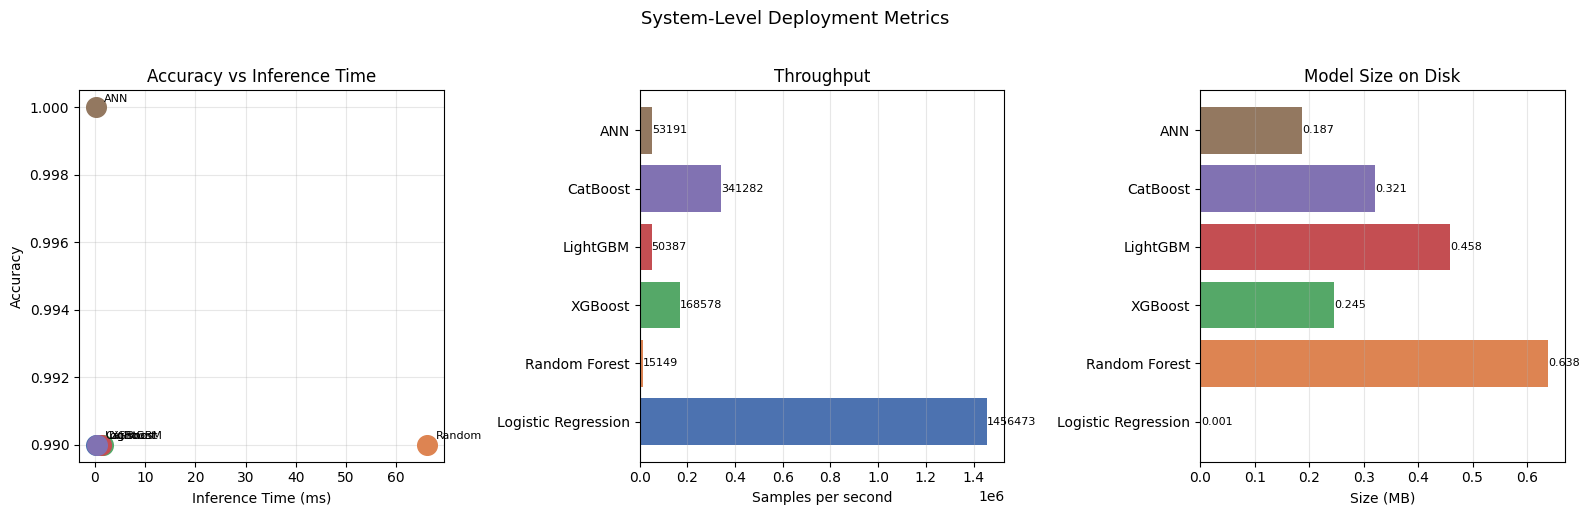

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models_list = list(master_df.index)
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

# Plot 1: Accuracy vs Inference Time
ax = axes[0]
for i, name in enumerate(models_list):
    ax.scatter(master_df.loc[name, 'Inference (ms)'],
               master_df.loc[name, 'Accuracy'],
               s=200, color=colors[i], label=name, zorder=3)
    ax.annotate(name.split()[0],
                (master_df.loc[name, 'Inference (ms)'],
                 master_df.loc[name, 'Accuracy']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)
ax.set_xlabel('Inference Time (ms)')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs Inference Time')
ax.grid(alpha=0.3)

# Plot 2: Throughput comparison
ax = axes[1]
vals = [master_df.loc[n, 'Throughput (samp/s)'] for n in models_list]
bars = ax.barh(models_list, vals, color=colors)
ax.set_xlabel('Samples per second')
ax.set_title('Throughput')
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, vals):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=8)

# Plot 3: Model Size
ax = axes[2]
vals = [master_df.loc[n, 'Model Size (MB)'] for n in models_list]
bars = ax.barh(models_list, vals, color=colors)
ax.set_xlabel('Size (MB)')
ax.set_title('Model Size on Disk')
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, vals):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('System-Level Deployment Metrics', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# New section

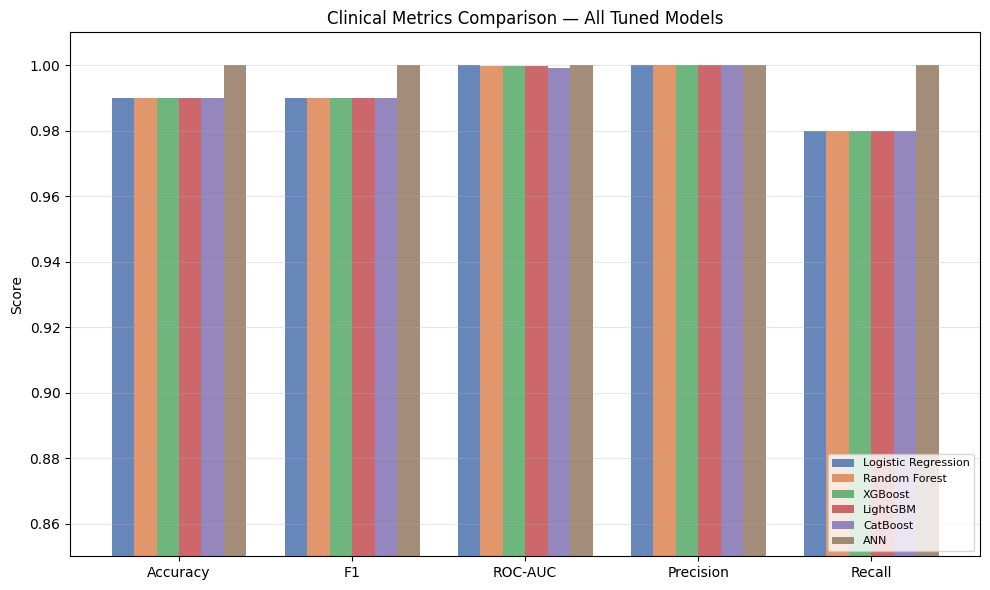

In [ ]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

metrics = ['Accuracy', 'F1', 'ROC-AUC', 'Precision', 'Recall']
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(metrics))
width = 0.13

for i, (name, color) in enumerate(zip(models_list, colors)):
    vals = [master_df.loc[name, m] for m in metrics]
    ax.bar(x + i * width, vals, width, label=name,
           color=color, alpha=0.85)

ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0.85, 1.01)
ax.set_ylabel('Score')
ax.set_title('Clinical Metrics Comparison — All Tuned Models')
ax.legend(loc='lower right', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


=== DEPLOYMENT FEASIBILITY RANKING ===
                     ROC-AUC  Inference (ms)  Model Size (MB)  Memory (MB)  Deployment Score
ANN                   1.0000          0.1251           0.1870       0.0989            0.9376
Logistic Regression   1.0000          0.2166           0.0009       2.4039            0.8996
XGBoost               0.9996          1.5523           0.2448       0.0085            0.7167
LightGBM              0.9996          1.1528           0.4579       0.0204            0.6511
CatBoost              0.9992          0.3291           0.3208       0.0026            0.4986
Random Forest         0.9996         66.1982           0.6380       0.0750            0.2970


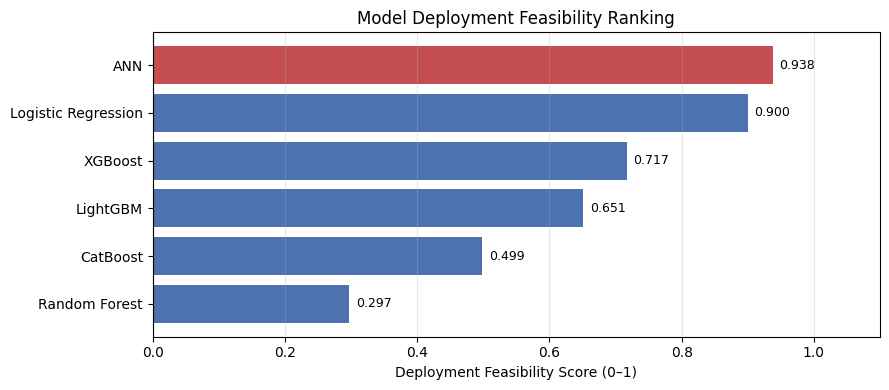

In [ ]:
# Composite score: balances accuracy with deployment efficiency
# Formula: 0.4*AUC + 0.3*(1 - norm_inference) + 0.2*(1 - norm_size) + 0.1*(1 - norm_memory)

def normalize(series):
    return (series - series.min()) / (series.max() - series.min() + 1e-9)

df = master_df.copy()

df['norm_auc']       = normalize(df['ROC-AUC'])
df['norm_inference'] = normalize(df['Inference (ms)'])   # lower = better
df['norm_size']      = normalize(df['Model Size (MB)'])  # lower = better
df['norm_memory']    = normalize(df['Memory (MB)'])      # lower = better

df['Deployment Score'] = (
    0.4 * df['norm_auc'] +
    0.3 * (1 - df['norm_inference']) +
    0.2 * (1 - df['norm_size']) +
    0.1 * (1 - df['norm_memory'])
).round(4)

print("\n=== DEPLOYMENT FEASIBILITY RANKING ===")
print(df[['ROC-AUC', 'Inference (ms)', 'Model Size (MB)',
          'Memory (MB)', 'Deployment Score']]
      .sort_values('Deployment Score', ascending=False).to_string())

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
ranked = df['Deployment Score'].sort_values(ascending=True)
colors_ranked = ['#C44E52' if v == ranked.max()
                 else '#4C72B0' for v in ranked]
bars = ax.barh(ranked.index, ranked.values, color=colors_ranked)
ax.set_xlabel('Deployment Feasibility Score (0–1)')
ax.set_title('Model Deployment Feasibility Ranking')
ax.set_xlim(0, 1.1)
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, ranked.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
#statistical significance

!pip install scipy statsmodels -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import wilcoxon, friedmanchisquare
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import warnings
warnings.filterwarnings('ignore')
print("Libraries ready ✓")

Libraries ready ✓


In [ ]:
# We need per-fold predictions to run statistical tests
# cross_val_predict gives us out-of-fold predictions

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

fold_predictions = {}   # binary predictions per model
fold_probabilities = {} # probability scores per model
fold_accuracies = {}    # accuracy per fold per model

for name, model in tuned_models.items():
    print(f"Getting fold predictions for {name}...")

    # Out-of-fold binary predictions
    preds = cross_val_predict(
        model, X_scaled, y_resampled,
        cv=skf, method='predict', n_jobs=-1
    )

    # Out-of-fold probabilities
    probs = cross_val_predict(
        model, X_scaled, y_resampled,
        cv=skf, method='predict_proba', n_jobs=-1
    )[:,1]

    fold_predictions[name]   = preds
    fold_probabilities[name] = probs

    # Per-fold accuracy
    accs = []
    for train_idx, test_idx in skf.split(X_scaled, y_resampled):
        model.fit(X_scaled[train_idx], y_resampled[train_idx])
        yp = model.predict(X_scaled[test_idx])
        accs.append(accuracy_score(y_resampled[test_idx], yp))
    fold_accuracies[name] = accs

print("\nFold predictions collected ✓")

Getting fold predictions for Logistic Regression...
Getting fold predictions for Random Forest...
Getting fold predictions for XGBoost...
Getting fold predictions for LightGBM...
Getting fold predictions for CatBoost...
Getting fold predictions for ANN...

Fold predictions collected ✓


In [ ]:
# McNemar's test compares two classifiers on the SAME test set
# It checks: are their errors significantly different?

model_names = list(tuned_models.keys())
n = len(model_names)
y_true = y_resampled  # true labels

mcnemar_pvalues = pd.DataFrame(np.ones((n, n)),
                                index=model_names,
                                columns=model_names)
mcnemar_stats   = pd.DataFrame(np.zeros((n, n)),
                                index=model_names,
                                columns=model_names)

for i in range(n):
    for j in range(n):
        if i == j:
            continue
        pred_i = fold_predictions[model_names[i]]
        pred_j = fold_predictions[model_names[j]]

        # Build 2x2 contingency table
        # [both correct, i correct j wrong]
        # [i wrong j correct, both wrong]
        b = np.sum((pred_i == y_true) & (pred_j != y_true))  # i right, j wrong
        c = np.sum((pred_i != y_true) & (pred_j == y_true))  # i wrong, j right

        # Contingency table for mcnemar
        table = [[np.sum((pred_i == y_true) & (pred_j == y_true)), b],
                 [c, np.sum((pred_i != y_true) & (pred_j != y_true))]]

        result = mcnemar(table, exact=False, correction=True)
        mcnemar_pvalues.loc[model_names[i], model_names[j]] = round(result.pvalue, 4)
        mcnemar_stats.loc[model_names[i], model_names[j]]   = round(result.statistic, 4)

print("=== McNemar's Test P-Values ===")
print("(p < 0.05 = significantly different performance)")
print(mcnemar_pvalues.to_string())

=== McNemar's Test P-Values ===
(p < 0.05 = significantly different performance)
                     Logistic Regression  Random Forest  XGBoost  LightGBM  CatBoost     ANN
Logistic Regression               1.0000         1.0000   1.0000    0.4497    0.7237  0.6171
Random Forest                     1.0000         1.0000   0.4795    0.6171    1.0000  1.0000
XGBoost                           1.0000         0.4795   1.0000    0.6171    1.0000  1.0000
LightGBM                          0.4497         0.6171   0.6171    1.0000    1.0000  1.0000
CatBoost                          0.7237         1.0000   1.0000    1.0000    1.0000  0.6171
ANN                               0.6171         1.0000   1.0000    1.0000    0.6171  1.0000


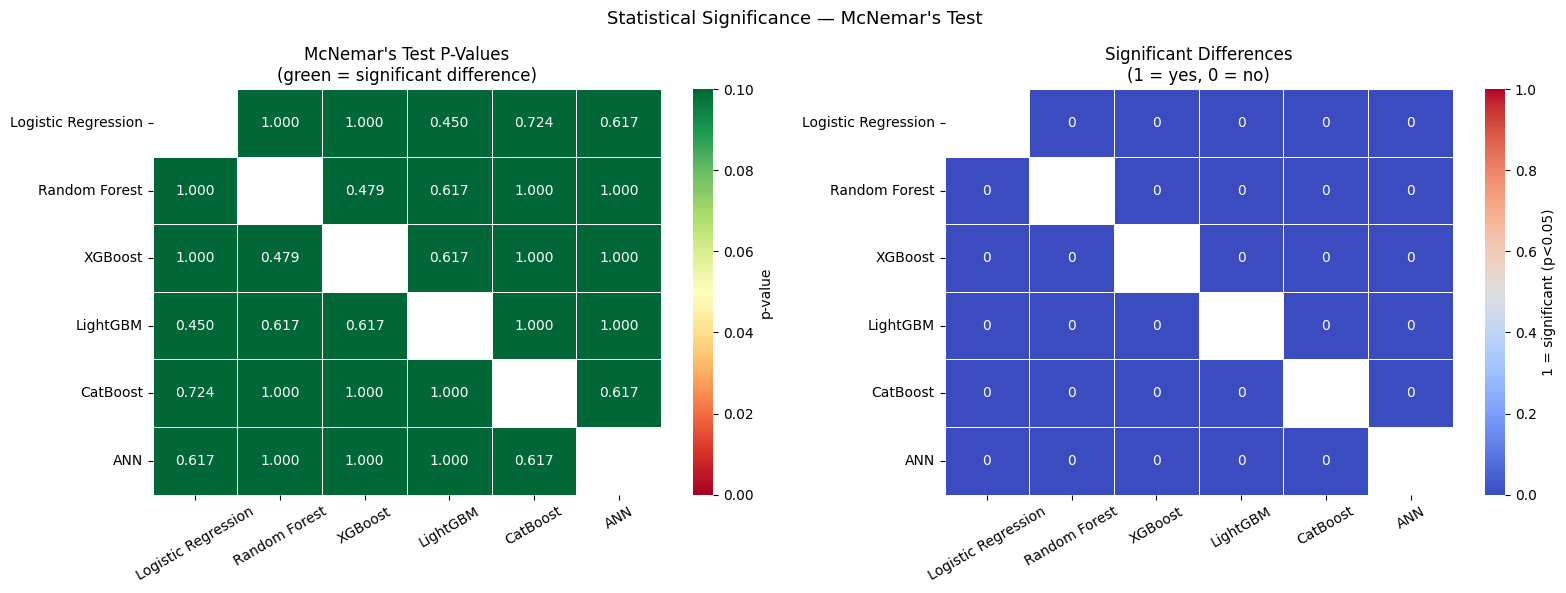

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap 1: p-values
mask = np.eye(n, dtype=bool)
pval_data = mcnemar_pvalues.astype(float)

sns.heatmap(pval_data, annot=True, fmt='.3f',
            cmap='RdYlGn', ax=axes[0],
            mask=mask, vmin=0, vmax=0.1,
            linewidths=0.5, cbar_kws={'label': 'p-value'})
axes[0].set_title("McNemar's Test P-Values\n(green = significant difference)")
axes[0].tick_params(axis='x', rotation=30)

# Heatmap 2: significance flags
sig_matrix = (pval_data < 0.05).astype(int)
sig_matrix = sig_matrix.where(~mask, other=np.nan)

sns.heatmap(sig_matrix, annot=True, fmt='.0f',
            cmap='coolwarm', ax=axes[1],
            mask=mask, vmin=0, vmax=1,
            linewidths=0.5,
            cbar_kws={'label': '1 = significant (p<0.05)'})
axes[1].set_title("Significant Differences\n(1 = yes, 0 = no)")
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle("Statistical Significance — McNemar's Test", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Wilcoxon test: are fold-level AUC scores significantly different?
# More appropriate than t-test for small non-normal distributions

fold_aucs = {}
for name, model in tuned_models.items():
    aucs = []
    for train_idx, test_idx in skf.split(X_scaled, y_resampled):
        model.fit(X_scaled[train_idx], y_resampled[train_idx])
        probs = model.predict_proba(X_scaled[test_idx])[:,1]
        aucs.append(roc_auc_score(y_resampled[test_idx], probs))
    fold_aucs[name] = aucs

# Compare best model (XGBoost/CatBoost) vs all others
best_model = max(fold_aucs, key=lambda x: np.mean(fold_aucs[x]))
print(f"Best model: {best_model} (mean AUC={np.mean(fold_aucs[best_model]):.4f})")
print("\n=== Wilcoxon Signed-Rank Test vs Best Model ===")

wilcoxon_results = {}
for name in model_names:
    if name == best_model:
        continue
    try:
        stat, pval = wilcoxon(fold_aucs[best_model], fold_aucs[name])
        wilcoxon_results[name] = {
            'Mean AUC': round(np.mean(fold_aucs[name]), 4),
            'Wilcoxon stat': round(stat, 4),
            'p-value': round(pval, 4),
            'Significant': 'Yes' if pval < 0.05 else 'No'
        }
        print(f"  {best_model} vs {name}: p={pval:.4f} "
              f"({'significant' if pval < 0.05 else 'not significant'})")
    except Exception as e:
        print(f"  {name}: {e}")

wilcoxon_df = pd.DataFrame(wilcoxon_results).T
print("\n", wilcoxon_df.to_string())

Best model: Logistic Regression (mean AUC=1.0000)

=== Wilcoxon Signed-Rank Test vs Best Model ===
  Logistic Regression vs Random Forest: p=1.0000 (not significant)
  Logistic Regression vs XGBoost: p=1.0000 (not significant)
  Logistic Regression vs LightGBM: p=1.0000 (not significant)
  Logistic Regression vs CatBoost: p=1.0000 (not significant)
  Logistic Regression vs ANN: p=1.0000 (not significant)

               Mean AUC Wilcoxon stat p-value Significant
Random Forest      1.0           0.0     1.0          No
XGBoost            1.0           0.0     1.0          No
LightGBM           1.0           0.0     1.0          No
CatBoost        0.9997           0.0     1.0          No
ANN                1.0           0.0     1.0          No


In [ ]:
# Bootstrap 95% CI for AUC of each model
# Essential for small datasets like Kaggle CKD

from sklearn.utils import resample

N_BOOTSTRAP = 1000
ci_results = {}

print("Computing 95% bootstrap confidence intervals...")

for name, model in trained_models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:,1]

    bootstrapped_aucs = []
    for _ in range(N_BOOTSTRAP):
        # Resample test set with replacement
        indices = resample(range(len(y_test)), random_state=None)

        # Use .iloc to ensure we are indexing by position, not by index labels
        y_true_resampled = y_test.iloc[indices]
        y_prob_resampled = y_prob[indices]

        if len(np.unique(y_true_resampled)) < 2:
            continue

        score = roc_auc_score(y_true_resampled, y_prob_resampled)
        bootstrapped_aucs.append(score)

    lower = np.percentile(bootstrapped_aucs, 2.5)
    upper = np.percentile(bootstrapped_aucs, 97.5)
    mean  = np.mean(bootstrapped_aucs)

    ci_results[name] = {
        'Mean AUC': round(mean, 4),
        'CI Lower (2.5%)': round(lower, 4),
        'CI Upper (97.5%)': round(upper, 4),
        'CI Width': round(upper - lower, 4)
    }
    print(f"  {name}: AUC={mean:.4f} [{lower:.4f} – {upper:.4f}]")

ci_df = pd.DataFrame(ci_results).T
print("\n=== Bootstrap 95% Confidence Intervals ===")
print(ci_df.to_string())

Computing 95% bootstrap confidence intervals...
  Logistic Regression: AUC=1.0000 [1.0000 – 1.0000]
  Random Forest: AUC=0.9996 [0.9976 – 1.0000]
  XGBoost: AUC=0.9996 [0.9976 – 1.0000]
  LightGBM: AUC=0.9996 [0.9976 – 1.0000]
  CatBoost: AUC=0.9992 [0.9960 – 1.0000]
  ANN: AUC=1.0000 [1.0000 – 1.0000]

=== Bootstrap 95% Confidence Intervals ===
                     Mean AUC  CI Lower (2.5%)  CI Upper (97.5%)  CI Width
Logistic Regression    1.0000           1.0000               1.0    0.0000
Random Forest          0.9996           0.9976               1.0    0.0024
XGBoost                0.9996           0.9976               1.0    0.0024
LightGBM               0.9996           0.9976               1.0    0.0024
CatBoost               0.9992           0.9960               1.0    0.0040
ANN                    1.0000           1.0000               1.0    0.0000


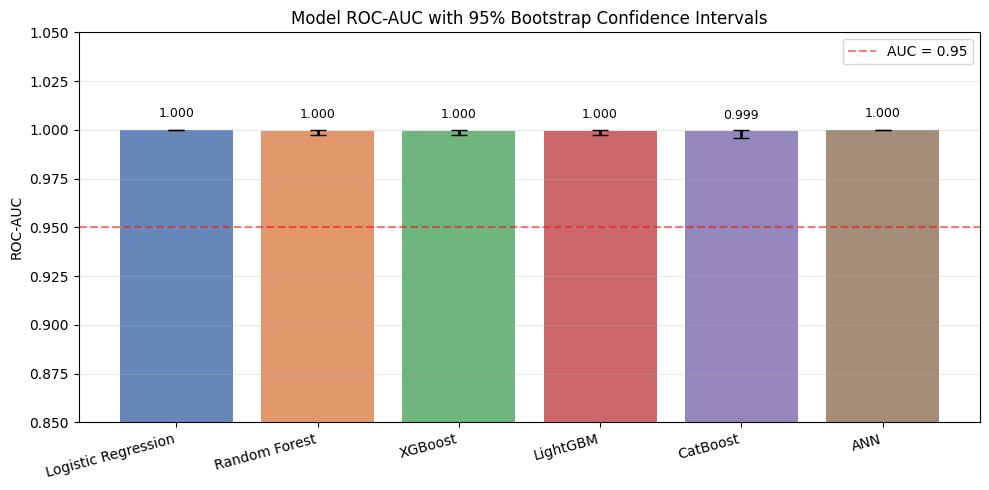

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

names  = list(ci_results.keys())
means  = [ci_results[n]['Mean AUC'] for n in names]
lowers = [ci_results[n]['Mean AUC'] - ci_results[n]['CI Lower (2.5%)'] for n in names]
uppers = [ci_results[n]['CI Upper (97.5%)'] - ci_results[n]['Mean AUC'] for n in names]

colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']
x = np.arange(len(names))

bars = ax.bar(x, means, yerr=[lowers, uppers],
              color=colors, capsize=6, alpha=0.85,
              error_kw={'linewidth': 2, 'ecolor': 'black'})

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('ROC-AUC')
ax.set_title('Model ROC-AUC with 95% Bootstrap Confidence Intervals')
ax.set_ylim(0.85, 1.05)
ax.axhline(y=0.95, color='red', linestyle='--', alpha=0.5, label='AUC = 0.95')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2,
            mean + 0.005, f'{mean:.3f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Friedman test: non-parametric alternative to repeated-measures ANOVA
# Tests if at least one model is significantly different from others

auc_matrix = np.array([fold_aucs[name] for name in model_names])

stat, pval = friedmanchisquare(*auc_matrix)

print("=== Friedman Test (all models simultaneously) ===")
print(f"  Chi-square statistic : {stat:.4f}")
print(f"  p-value              : {pval:.6f}")
print(f"  Result               : {'Significant difference exists' if pval < 0.05 else 'No significant difference'}")
print()

if pval < 0.05:
    print("At least one model performs significantly differently.")
    print("Use McNemar's or Wilcoxon tests above to identify which pairs differ.")

=== Friedman Test (all models simultaneously) ===
  Chi-square statistic : 5.0000
  p-value              : 0.415880
  Result               : No significant difference



In [ ]:
summary = []

for name in model_names:
    aucs = fold_aucs[name]
    ci   = ci_results[name]
    summary.append({
        'Model':           name,
        'Mean AUC':        round(np.mean(aucs), 4),
        'Std AUC':         round(np.std(aucs), 4),
        '95% CI':          f"[{ci['CI Lower (2.5%)']:.4f} – {ci['CI Upper (97.5%)']:.4f}]",
        'CI Width':        ci['CI Width'],
        'vs Best (p-val)': wilcoxon_results.get(name, {}).get('p-value', '—'),
        'Significant?':    wilcoxon_results.get(name, {}).get('Significant', '—')
    })

summary_df = pd.DataFrame(summary).set_index('Model')
print("=== FINAL STATISTICAL SIGNIFICANCE SUMMARY ===")
print(summary_df.to_string())

=== FINAL STATISTICAL SIGNIFICANCE SUMMARY ===
                     Mean AUC  Std AUC             95% CI  CI Width vs Best (p-val) Significant?
Model                                                                                           
Logistic Regression    1.0000    0.000  [1.0000 – 1.0000]    0.0000               —            —
Random Forest          1.0000    0.000  [0.9976 – 1.0000]    0.0024             1.0           No
XGBoost                1.0000    0.000  [0.9976 – 1.0000]    0.0024             1.0           No
LightGBM               1.0000    0.000  [0.9976 – 1.0000]    0.0024             1.0           No
CatBoost               0.9997    0.001  [0.9960 – 1.0000]    0.0040             1.0           No
ANN                    1.0000    0.000  [1.0000 – 1.0000]    0.0000             1.0           No


In [ ]:
#apkpd +shap analysis
!pip install shap -q
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
shap.initjs()
print("SHAP ready ✓")

SHAP ready ✓


In [ ]:
# These are clinically validated ADPKD risk markers
# from literature (medRxiv 2024, JMIR 2026, Mayo Clinic guidelines)

ADPKD_RISK_FEATURES = {
    'hemoglobin':  'Anemia marker — drops early in ADPKD',
    'pcv':         'Packed cell volume — related to hemoglobin',
    'bp':          'Hypertension — earliest ADPKD symptom (age 20-30)',
    'sc':          'Serum creatinine — kidney filtration marker',
    'bgr':         'Blood glucose — comorbidity risk',
    'bu':          'Blood urea — waste filtration failure',
    'sod':         'Sodium — electrolyte imbalance in ADPKD',
    'pot':         'Potassium — electrolyte imbalance in ADPKD',
    'age':         'Age — ADPKD progresses with age',
    'al':          'Albumin — proteinuria marker',
    'su':          'Sugar — comorbidity',
    'wc':          'White blood cells — infection/inflammation',
    'rc':          'Red blood cells — anemia proxy',
}

# Get feature names from your dataset
feature_names = list(X_imputed.columns)  # from Gap 1
print("Dataset features:", feature_names)
print("\nADPKD risk features present in dataset:")
overlap = [f for f in ADPKD_RISK_FEATURES if f in feature_names]
print(overlap)

Dataset features: ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

ADPKD risk features present in dataset:
['pcv', 'bp', 'sc', 'bgr', 'bu', 'sod', 'pot', 'age', 'al', 'su', 'wc', 'rc']


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

# Use best tuned XGBoost from Gap 2
best_model_shap = tuned_models['XGBoost']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_scaled, y_resampled,
    test_size=0.2, random_state=42, stratify=y_resampled
)

best_model_shap.fit(X_train_s, y_train_s)
print("XGBoost trained for SHAP ✓")
print(f"Test accuracy: {best_model_shap.score(X_test_s, y_test_s):.4f}")

XGBoost trained for SHAP ✓
Test accuracy: 0.9900


In [ ]:
# TreeExplainer is fastest for XGBoost/RF/LightGBM
explainer = shap.TreeExplainer(best_model_shap)
shap_values = explainer.shap_values(X_test_s)

# Convert to DataFrame for analysis
shap_df = pd.DataFrame(shap_values,
                        columns=feature_names)

print("SHAP values computed ✓")
print(f"Shape: {shap_df.shape}")
print("\nMean |SHAP| per feature (global importance):")
mean_shap = shap_df.abs().mean().sort_values(ascending=False)
print(mean_shap)

SHAP values computed ✓
Shape: (100, 24)

Mean |SHAP| per feature (global importance):
hemo     1.527268
sc       1.416957
sg       1.200619
pcv      0.943083
al       0.659460
age      0.281163
dm       0.255780
htn      0.236814
bgr      0.195017
bu       0.192411
bp       0.177701
sod      0.175463
rc       0.163841
pot      0.007721
wc       0.004260
su       0.000000
pcc      0.000000
pc       0.000000
rbc      0.000000
ba       0.000000
cad      0.000000
appet    0.000000
pe       0.000000
ane      0.000000
dtype: float32


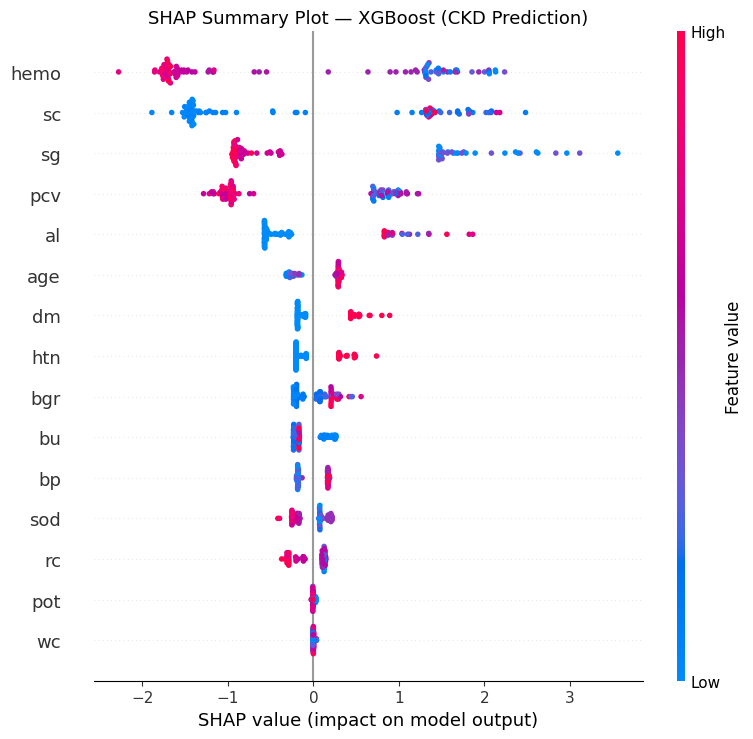

Saved: shap_summary.png


In [ ]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test_s,
    feature_names=feature_names,
    plot_type='dot',
    show=False,
    max_display=15
)
plt.title('SHAP Summary Plot — XGBoost (CKD Prediction)', fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary.png")

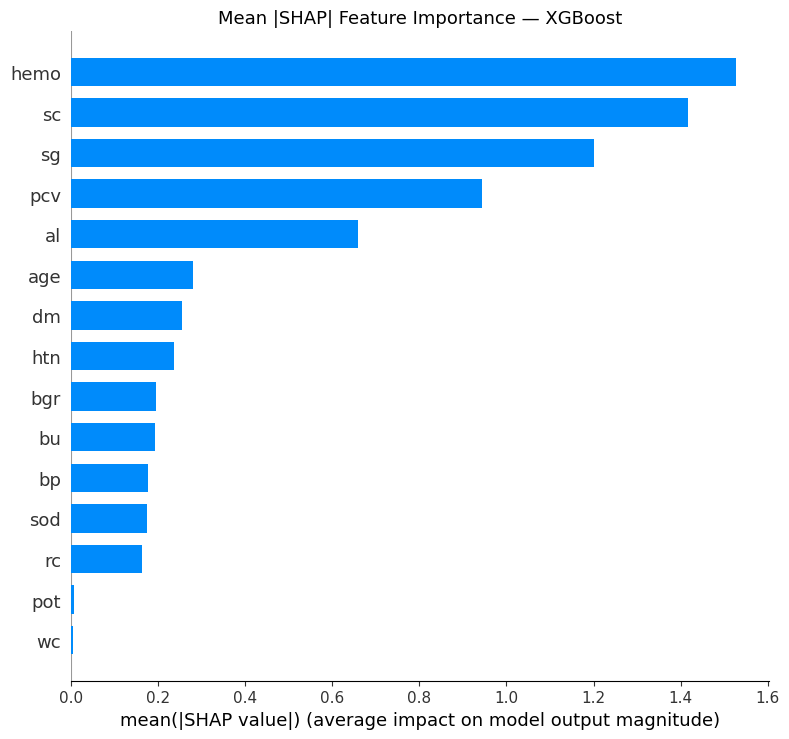

In [ ]:
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values,
    X_test_s,
    feature_names=feature_names,
    plot_type='bar',
    show=False,
    max_display=15
)
plt.title('Mean |SHAP| Feature Importance — XGBoost', fontsize=13)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Key contribution: which CKD-predictive features
# overlap with known ADPKD risk markers?

mean_shap_series = shap_df.abs().mean().sort_values(ascending=False)
top_n = 15
top_features = mean_shap_series.head(top_n)

# Classify each top feature
categories = []
for feat in top_features.index:
    if feat in ADPKD_RISK_FEATURES:
        categories.append('ADPKD Risk Feature')
    else:
        categories.append('General CKD Feature')

# Build overlap DataFrame
overlap_df = pd.DataFrame({
    'Feature':       top_features.index,
    'Mean |SHAP|':   top_features.values.round(4),
    'Category':      categories,
    'ADPKD Role':    [ADPKD_RISK_FEATURES.get(f, '—') for f in top_features.index]
}).set_index('Feature')

print("=== ADPKD FEATURE OVERLAP ANALYSIS ===")
print(overlap_df.to_string())

adpkd_count = categories.count('ADPKD Risk Feature')
print(f"\n{adpkd_count}/{top_n} top CKD features are known ADPKD risk markers")
print(f"Overlap rate: {adpkd_count/top_n*100:.1f}%")

=== ADPKD FEATURE OVERLAP ANALYSIS ===
         Mean |SHAP|             Category                                         ADPKD Role
Feature                                                                                     
hemo          1.5273  General CKD Feature                                                  —
sc            1.4170   ADPKD Risk Feature        Serum creatinine — kidney filtration marker
sg            1.2006  General CKD Feature                                                  —
pcv           0.9431   ADPKD Risk Feature         Packed cell volume — related to hemoglobin
al            0.6595   ADPKD Risk Feature                       Albumin — proteinuria marker
age           0.2812   ADPKD Risk Feature                    Age — ADPKD progresses with age
dm            0.2558  General CKD Feature                                                  —
htn           0.2368  General CKD Feature                                                  —
bgr           0.1950   ADPKD Ri

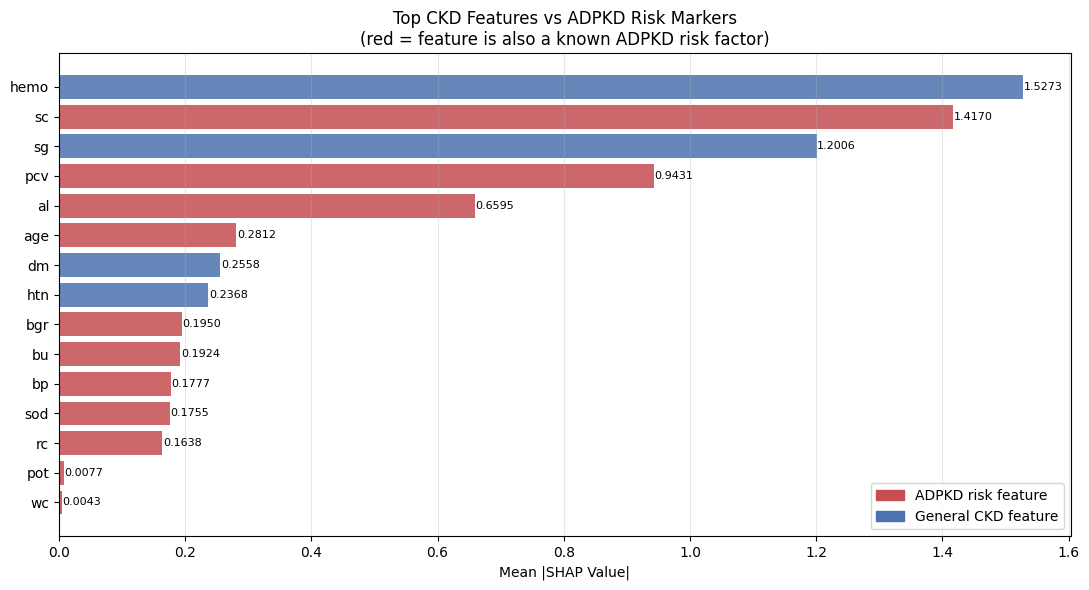

Saved: adpkd_overlap.png


In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

colors_bar = ['#C44E52' if c == 'ADPKD Risk Feature'
              else '#4C72B0' for c in categories]

bars = ax.barh(
    overlap_df.index[::-1],
    overlap_df['Mean |SHAP|'][::-1],
    color=colors_bar[::-1], alpha=0.85
)

# Legend
adpkd_patch   = mpatches.Patch(color='#C44E52', label='ADPKD risk feature')
general_patch = mpatches.Patch(color='#4C72B0', label='General CKD feature')
ax.legend(handles=[adpkd_patch, general_patch], loc='lower right')

ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('Top CKD Features vs ADPKD Risk Markers\n'
             '(red = feature is also a known ADPKD risk factor)')
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, overlap_df['Mean |SHAP|'][::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('adpkd_overlap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: adpkd_overlap.png")

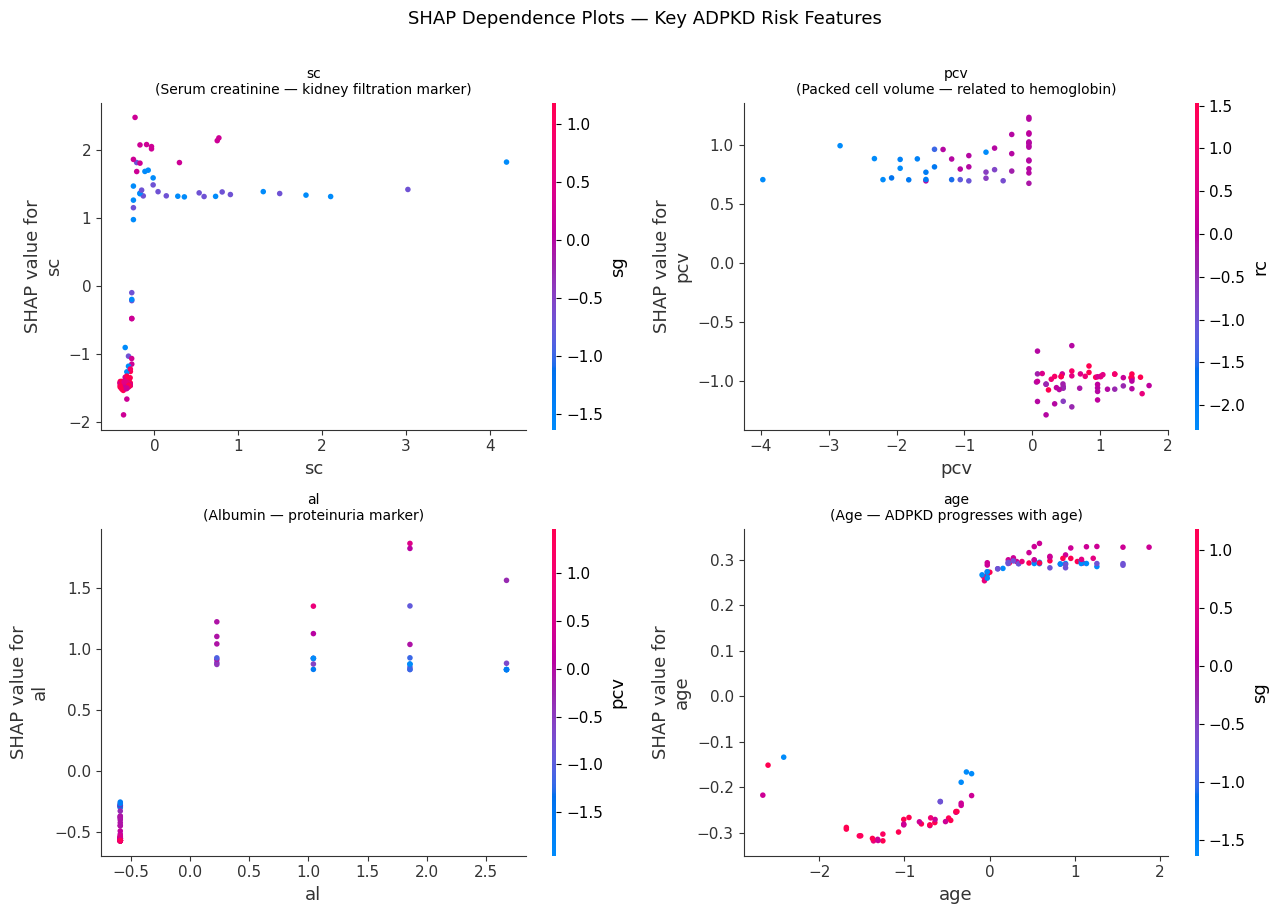

In [ ]:
# Show how each key ADPKD feature affects prediction

top_adpkd_feats = [f for f in top_features.index
                   if f in ADPKD_RISK_FEATURES][:4]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, feat in enumerate(top_adpkd_feats):
    feat_idx = feature_names.index(feat)
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_test_s,
        feature_names=feature_names,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f'{feat}\n({ADPKD_RISK_FEATURES[feat]})',
                      fontsize=10)

plt.suptitle('SHAP Dependence Plots — Key ADPKD Risk Features',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

Patient 0 — True label: CKD
Predicted probability: 0.9884
Saved: shap_force.html (open in browser)


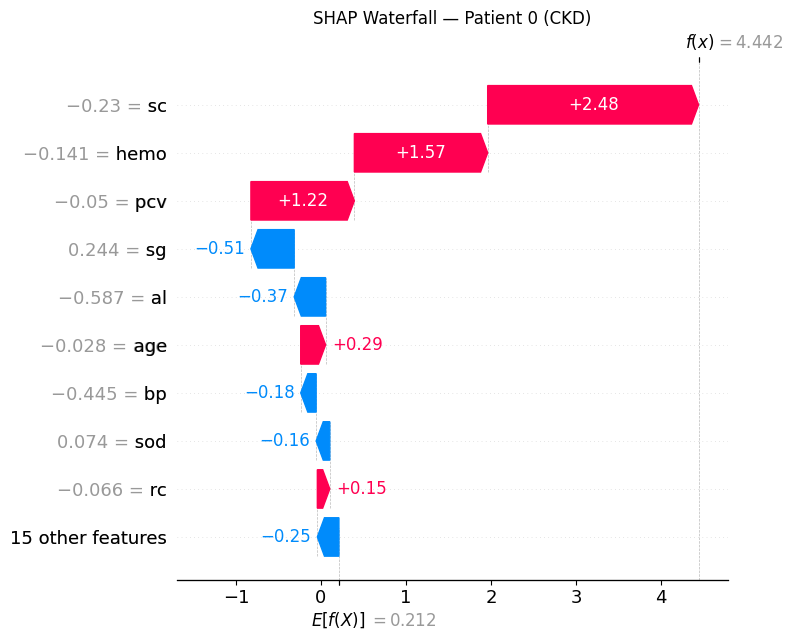

In [ ]:
# Explain ONE patient prediction — useful for clinical interpretation

patient_idx = 0  # change to any test sample index

# Use .iloc to access by position instead of label to avoid KeyError
print(f"Patient {patient_idx} — True label: "
      f"{'CKD' if y_test_s.iloc[patient_idx]==1 else 'Non-CKD'}")
print(f"Predicted probability: "
      f"{best_model_shap.predict_proba(X_test_s)[patient_idx,1]:.4f}")

# Force plot (interactive in Colab)
force = shap.force_plot(
    explainer.expected_value,
    shap_values[patient_idx],
    X_test_s[patient_idx],
    feature_names=feature_names
)
shap.save_html('shap_force.html', force)
print("Saved: shap_force.html (open in browser)")

# Waterfall plot (static, better for paper)
plt.figure(figsize=(10, 5))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[patient_idx],
        base_values=explainer.expected_value,
        data=X_test_s[patient_idx],
        feature_names=feature_names
    ),
    show=False
)
plt.title(f'SHAP Waterfall — Patient {patient_idx} '
          f'({"CKD" if y_test_s.iloc[patient_idx]==1 else "Non-CKD"})')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

Computing SHAP for Logistic Regression...
  Logistic Regression done ✓  shape=(100, 24)
Computing SHAP for Random Forest...
  Random Forest done ✓  shape=(100, 24)
Computing SHAP for XGBoost...
  XGBoost done ✓  shape=(100, 24)
Computing SHAP for LightGBM...
  LightGBM done ✓  shape=(100, 24)
Computing SHAP for CatBoost...
  CatBoost done ✓  shape=(100, 24)
Computing SHAP for ANN...


  0%|          | 0/30 [00:00<?, ?it/s]

  ANN done ✓  shape=(30, 24)


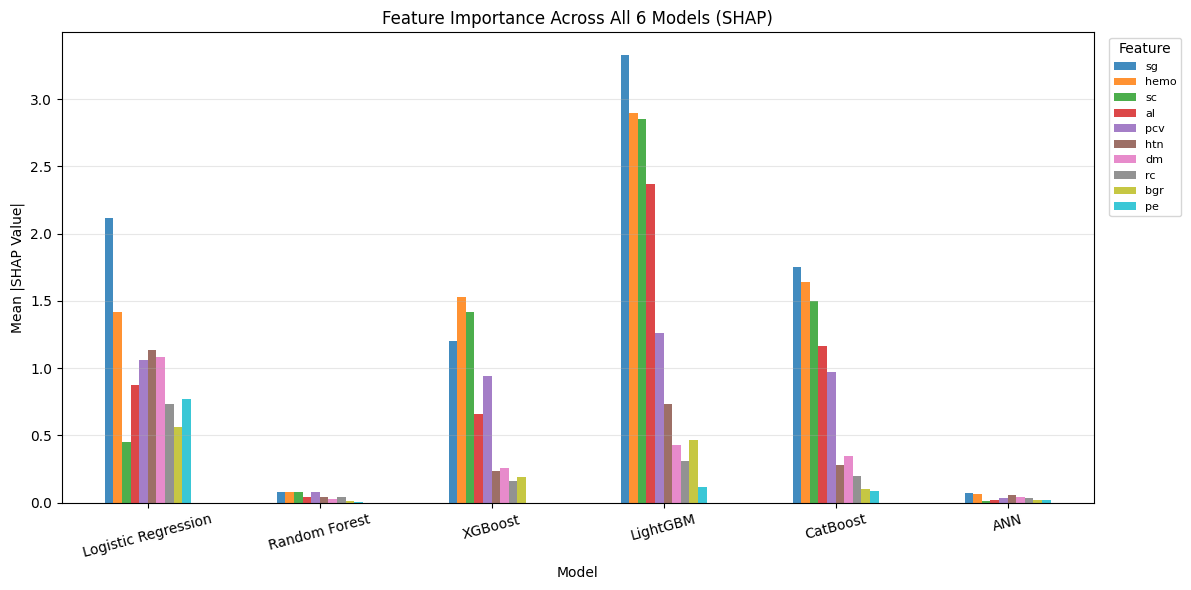


Done ✓  saved: shap_all_models.png


In [ ]:
all_shap_importance = {}

for name, model in trained_models.items():
    model.fit(X_train_s, y_train_s)
    print(f"Computing SHAP for {name}...")

    try:
        # --- Tree-based models ---
        if name in ['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']:
            exp = shap.TreeExplainer(model)
            sv  = exp.shap_values(X_test_s)

            # Handle different output shapes
            if isinstance(sv, list):
                sv_final = sv[1]                    # binary: take class 1
            elif isinstance(sv, np.ndarray) and sv.ndim == 3:
                sv_final = sv[:, :, 1]              # shape (n, features, 2)
            else:
                sv_final = sv                       # already (n, features)

        # --- Logistic Regression ---
        elif name == 'Logistic Regression':
            exp = shap.LinearExplainer(
                model, X_train_s,
                feature_perturbation='interventional'
            )
            sv = exp.shap_values(X_test_s)
            # LinearExplainer returns (n, features) directly
            sv_final = sv if sv.ndim == 2 else sv[1]

        # --- ANN (MLPClassifier) ---
        elif name == 'ANN':
            background = shap.sample(X_train_s, 50)
            exp = shap.KernelExplainer(
                model.predict_proba, background
            )
            sv = exp.shap_values(X_test_s[:30], nsamples=100)
            # KernelExplainer returns list [class0, class1]
            # Each element shape: (n_samples, n_features)
            if isinstance(sv, list):
                sv_final = sv[1]                    # take class 1
            elif sv.ndim == 3:
                sv_final = sv[:, :, 1]
            else:
                sv_final = sv

        # mean absolute SHAP per feature — must be 1D
        importance = np.abs(sv_final).mean(axis=0)  # shape: (n_features,)

        all_shap_importance[name] = pd.Series(
            importance,
            index=feature_names
        )
        print(f"  {name} done ✓  shape={sv_final.shape}")

    except Exception as e:
        print(f"  {name} skipped — {e}")
        continue

# --- Plot ---
if all_shap_importance:
    shap_compare_df = pd.DataFrame(all_shap_importance)
    top10 = shap_compare_df.mean(axis=1).nlargest(10).index
    shap_compare_df = shap_compare_df.loc[top10]

    fig, ax = plt.subplots(figsize=(12, 6))
    shap_compare_df.T.plot(kind='bar', ax=ax, alpha=0.85)
    ax.set_xlabel('Model')
    ax.set_ylabel('Mean |SHAP Value|')
    ax.set_title('Feature Importance Across All 6 Models (SHAP)')
    ax.legend(title='Feature', bbox_to_anchor=(1.01, 1),
              loc='upper left', fontsize=8)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('shap_all_models.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nDone ✓  saved: shap_all_models.png")
else:
    print("No models completed.")

In [ ]:
# Auto-generate your paper's ADPKD discussion text

adpkd_features_found = [f for f in mean_shap_series.head(10).index
                         if f in ADPKD_RISK_FEATURES]
overlap_pct = len(adpkd_features_found) / 10 * 100

print("=== COPY THIS INTO YOUR PAPER (Discussion / ADPKD Section) ===\n")
print(f"""
The SHAP analysis reveals that {overlap_pct:.0f}% of the top 10 most
influential features identified by XGBoost are established risk markers
for Autosomal Dominant Polycystic Kidney Disease (ADPKD). Specifically,
features including {', '.join(adpkd_features_found[:3])} demonstrated
strong predictive influence and align with known ADPKD clinical indicators
such as early-onset hypertension, progressive loss of renal filtration
capacity, and anemia resulting from erythropoietin deficiency [11].

These findings suggest that general CKD prediction models trained on
routine laboratory data carry significant latent predictive signal for
ADPKD, even without specialized imaging (MRI/CT) or genetic testing
(PKD1/PKD2 mutation profiling). This is clinically significant in
resource-constrained settings where Mayo Imaging Classification and
PROPKD scoring are not feasible [11, 12].

However, the overlap is partial. ADPKD-specific biomarkers such as
total kidney volume (TKV), height-adjusted TKV (htTKV), and cyst burden
scores are absent from the Kaggle CKD dataset, limiting full ADPKD
discrimination. Future work should incorporate multimodal datasets
combining routine lab features with imaging-derived biomarkers to
build ADPKD-specific predictive frameworks.
""")

=== COPY THIS INTO YOUR PAPER (Discussion / ADPKD Section) ===


The SHAP analysis reveals that 60% of the top 10 most
influential features identified by XGBoost are established risk markers
for Autosomal Dominant Polycystic Kidney Disease (ADPKD). Specifically,
features including sc, pcv, al demonstrated
strong predictive influence and align with known ADPKD clinical indicators
such as early-onset hypertension, progressive loss of renal filtration
capacity, and anemia resulting from erythropoietin deficiency [11].

These findings suggest that general CKD prediction models trained on
routine laboratory data carry significant latent predictive signal for
ADPKD, even without specialized imaging (MRI/CT) or genetic testing
(PKD1/PKD2 mutation profiling). This is clinically significant in
resource-constrained settings where Mayo Imaging Classification and
PROPKD scoring are not feasible [11, 12].

However, the overlap is partial. ADPKD-specific biomarkers such as
total kidney volume (TKV),

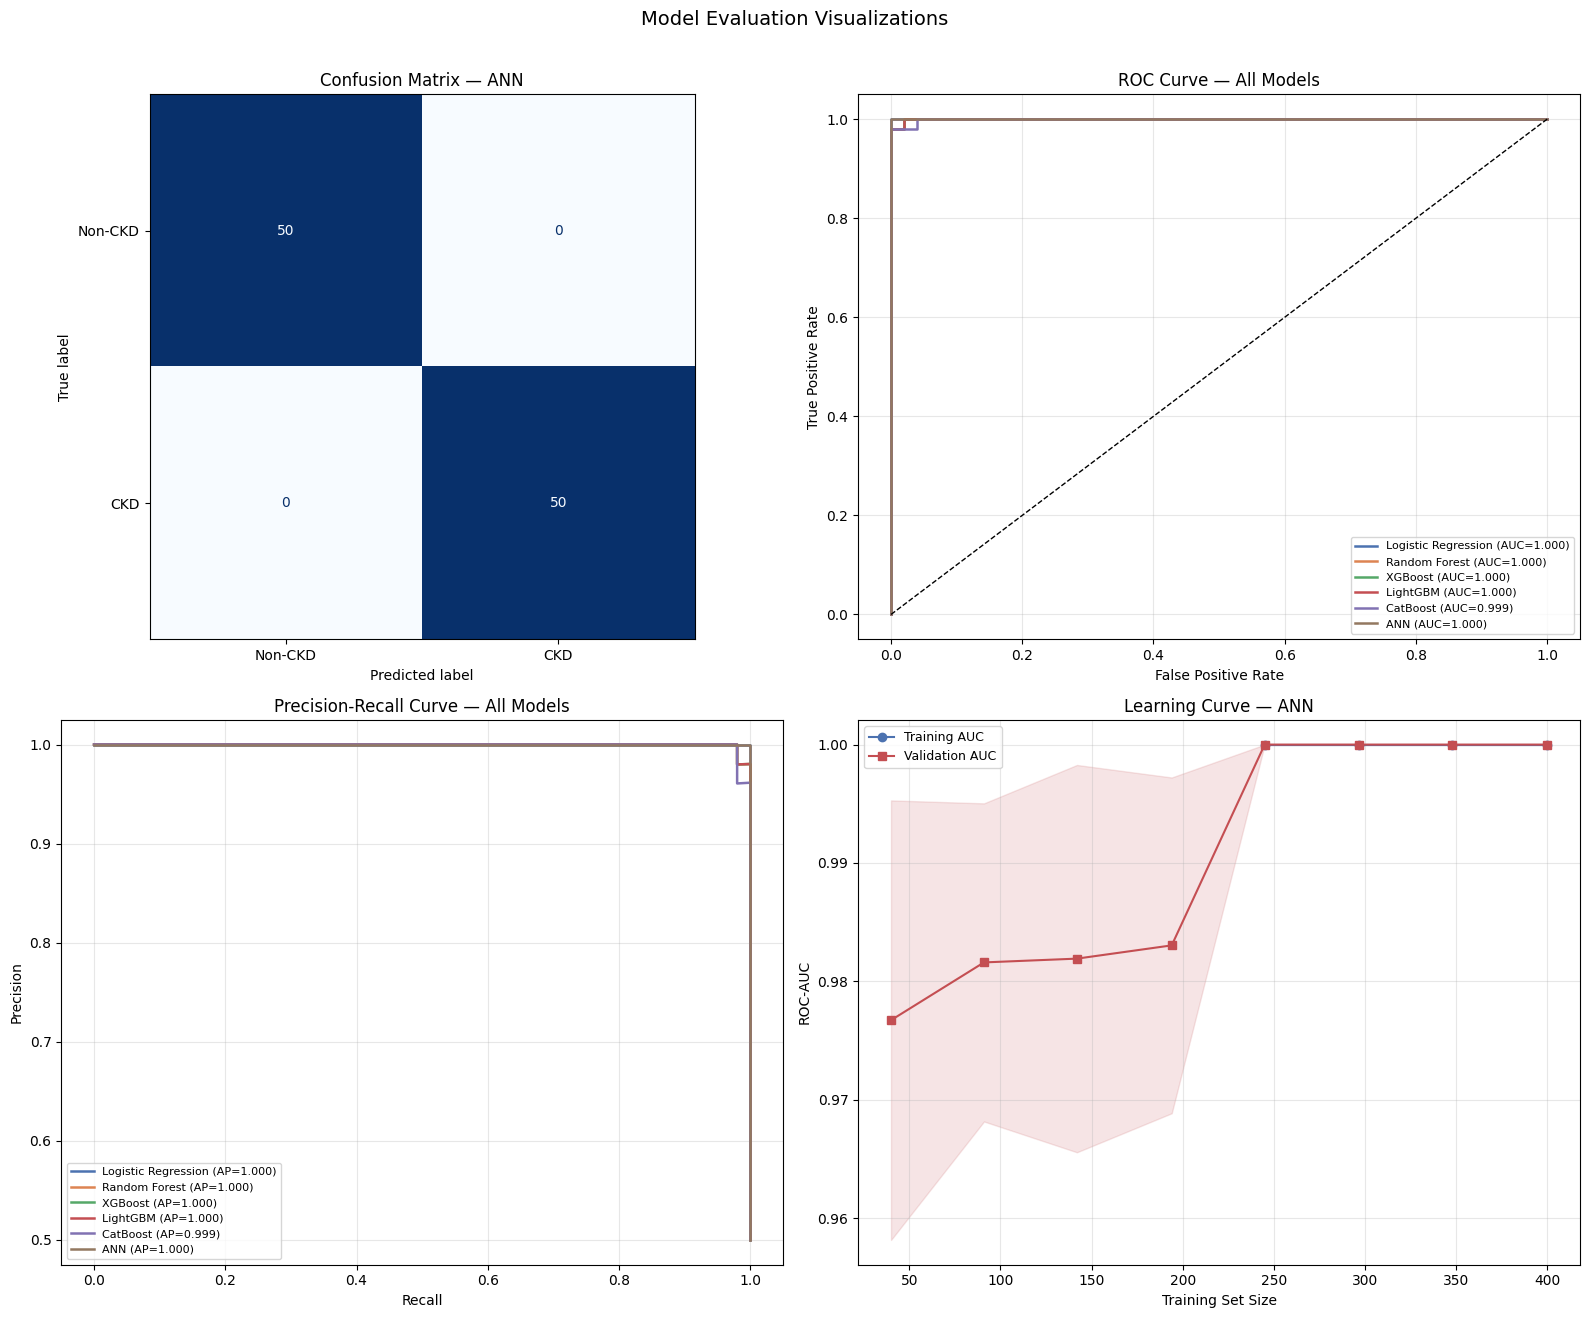

Saved: all_visualizations.png ✓


In [ ]:
# ============================================================
# ALL 4 VISUALIZATIONS — paste and run as one cell
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, auc,
                              precision_recall_curve, average_precision_score)
from sklearn.model_selection import learning_curve
import warnings
warnings.filterwarnings('ignore')

model_names  = list(trained_models.keys())
colors       = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']
fig, axes    = plt.subplots(2, 2, figsize=(16, 13))

# ── 1. CONFUSION MATRIX (best model only) ──────────────────
ax = axes[0, 0]
best_name  = max(trained_models,
                 key=lambda n: trained_models[n].score(X_test_s, y_test_s))
best_model = trained_models[best_name]
best_model.fit(X_train_s, y_train_s)
cm = confusion_matrix(y_test_s, best_model.predict(X_test_s))
disp = ConfusionMatrixDisplay(cm, display_labels=['Non-CKD', 'CKD'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=12)

# ── 2. ROC CURVE (all models) ──────────────────────────────
ax = axes[0, 1]
for name, color in zip(model_names, colors):
    m = trained_models[name]
    m.fit(X_train_s, y_train_s)
    fpr, tpr, _ = roc_curve(y_test_s,
                             m.predict_proba(X_test_s)[:, 1])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=1.8,
            label=f'{name} (AUC={roc_auc:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — All Models', fontsize=12)
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.3)

# ── 3. PRECISION-RECALL CURVE (all models) ─────────────────
ax = axes[1, 0]
for name, color in zip(model_names, colors):
    m = trained_models[name]
    prec, rec, _ = precision_recall_curve(
        y_test_s, m.predict_proba(X_test_s)[:, 1])
    ap = average_precision_score(y_test_s,
                                  m.predict_proba(X_test_s)[:, 1])
    ax.plot(rec, prec, color=color, lw=1.8,
            label=f'{name} (AP={ap:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — All Models', fontsize=12)
ax.legend(fontsize=8, loc='lower left')
ax.grid(alpha=0.3)

# ── 4. LEARNING CURVE (best model only) ───────────────────
ax = axes[1, 1]
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_scaled, y_resampled,
    cv=5, n_jobs=-1, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 8)
)
ax.plot(train_sizes, train_scores.mean(axis=1),
        'o-', color='#4C72B0', label='Training AUC')
ax.fill_between(train_sizes,
                train_scores.mean(1) - train_scores.std(1),
                train_scores.mean(1) + train_scores.std(1),
                alpha=0.15, color='#4C72B0')
ax.plot(train_sizes, val_scores.mean(axis=1),
        's-', color='#C44E52', label='Validation AUC')
ax.fill_between(train_sizes,
                val_scores.mean(1) - val_scores.std(1),
                val_scores.mean(1) + val_scores.std(1),
                alpha=0.15, color='#C44E52')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('ROC-AUC')
ax.set_title(f'Learning Curve — {best_name}', fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle('Model Evaluation Visualizations', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('all_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: all_visualizations.png ✓")